# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.

   https://www.kaggle.com/datasets/usmanlovescode/indonesia-food-prices-dataset


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [145]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [146]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/SML_Sebastian-abe-santoso/wfpfoodpricesidn_raw.csv')

print(f"Shape: {df.shape}\n")
print(f"Columns: {df.columns.tolist()}\n")
print(f"Missing Values: {df.isnull().sum()}\n")

if str(df.iloc[0, 0]).startswith('#'):
    df = df.iloc[1:].reset_index(drop=True)

df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['latitude'] = pd.to_numeric(df['latitude'], errors='coerce')
df['longitude'] = pd.to_numeric(df['longitude'], errors='coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['usdprice'] = pd.to_numeric(df['usdprice'], errors='coerce')

df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (264564, 14)

Columns: ['date', 'admin1', 'admin2', 'market', 'latitude', 'longitude', 'category', 'commodity', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice']

Missing Values: date            0
admin1       1663
admin2       1663
market          0
latitude     1663
longitude    1663
category        0
commodity       0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264563 entries, 0 to 264562
Data columns (total 14 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       264563 non-null  datetime64[ns]
 1   admin1     262900 non-null  object        
 2   admin2     262900 non-null  object        
 3   market     264563 non-null  object        
 4 

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

2007-01-15 00:00:00 2023-11-15 00:00:00


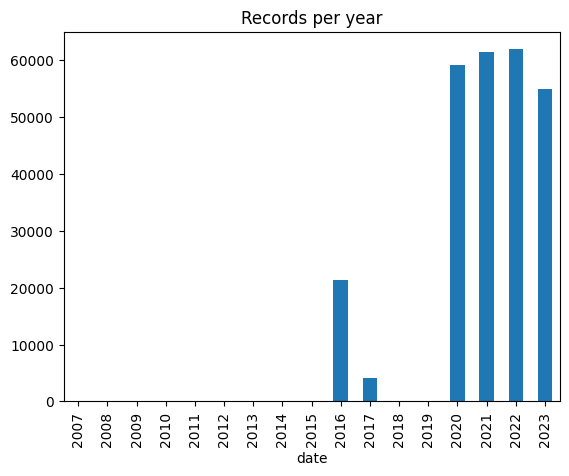

In [147]:
print(df['date'].min(), df['date'].max())
df.groupby(df['date'].dt.year).size().plot(kind='bar', title='Records per year')
plt.show()

In [148]:
print("Commodities:", df['commodity'].nunique())
print("\nProvinces (admin1):", df['admin1'].nunique())
print("\nMarkets:", df['market'].nunique())
print("\nCategories:", df['category'].nunique())

Commodities: 30

Provinces (admin1): 34

Markets: 215

Categories: 7


In [149]:
df['commodity'].value_counts().head(20)

,count
commodity,
Chili (red),10994
Eggs,10993
Oil (vegetable),10992
Chili (bird's eye),10991
Sugar,10990
Onions (shallot),10836
Garlic,10836
"Meat (chicken, broiler)",10821
Rice (high quality),10777


In [150]:
df['category'].value_counts()

,count
category,
vegetables and fruits,98429
"meat, fish and eggs",72210
cereals and tubers,39140
miscellaneous food,27377
oil and fats,27165
milk and dairy,158
non-food,84


In [151]:
df['currency'].value_counts()

,count
currency,
IDR,264563


In [152]:
df['unit'].value_counts()

,count
unit,
KG,264163
L,242
385 G,158


In [153]:
df['price'].describe()

,price
count,264563.000000
mean,38541.041617
std,34491.875430
min,1630.650000
25%,15000.000000
50%,27400.000000
75%,41631.580000
max,215000.000000


In [154]:
df[df['admin1'].isnull()]['market'].value_counts()

,count
market,
National Average,1663


In [155]:
df.duplicated().sum()

np.int64(0)

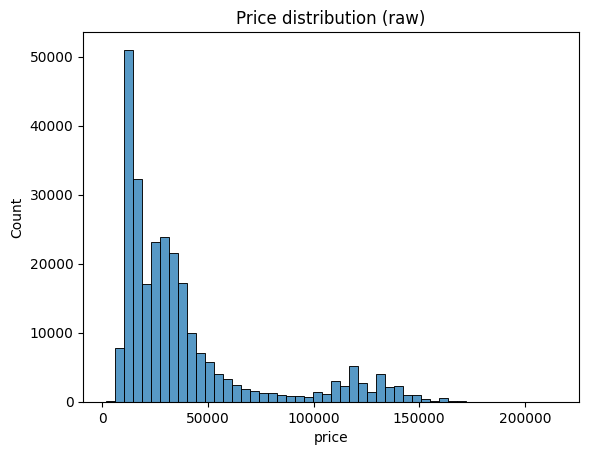

In [156]:
sns.histplot(df['price'], bins=50)
plt.title('Price distribution (raw)')
plt.show()

## Ringkasan EDA & Keputusan Preprocessing

* **Rentang**: Data mencakup rentang 2007 - 2023, tetapi sangat tidak merata,  
  terkonsentrasi di 2020 - 2023, dengan lonjakan kecil di 2016 dan hampir kosong di 2007 - 2015 serta 2018 - 2019.
  
  - Keputusan: batasi data pelatihan mulai dari 2020 agar fitur lag/rolling average, lebih andal dan tidak melompati rentang waktu yang kosong.

* **Komoditas**: Terdapat 30 komoditas, beberapa di antaranya adalah varian yang mirip
  satu sama lain (misalnya Rice / Rice high quality / Rice low quality).
  - Keputusan: tetap pertahankan sebagai kategori terpisah untuk saat ini (menjaga granularitas untuk use case UMKM). Konsolidasi varian hanya dipertimbangkan jika jumlah data suatu varian terlalu sedikit setelah filter tanggal diterapkan.

* **Mata uang**: 100% dalam IDR, tidak diperlukan konversi mata uang, kolom `price` bisa langsung digunakan.

* **Satuan (unit)**: 99,85% dalam KG, sisanya dalam L dan "385 G".
  - Keputusan: filter data agar hanya menyertakan `unit == 'KG'`, buang ±400 baris dengan satuan selain KG.

* **Nilai kosong (missing values)**: Terdapat 1663 baris (±0,63% dari total data)
  Yang kosong pada admin1/admin2/latitude/longitude, seluruhnya berasal dari satu entri pasar bernama "National Average".
  - Keputusan: hapus baris-baris ini karena berada di luar cakupan proyek (proyek ini berfokus pada prediksi harga tingkat provinsi/pasar, bukan rata-rata nasional).

- **Duplikasi data**: Tidak ditemukan baris duplikat sama sekali (0 dari 264.563 baris).
  - Tidak diperlukan penanganan lebih lanjut untuk duplikasi.

* **Distribusi harga**: Distribusi miring ke kanan (mean 38.541 > median 27.400 IDR),
  hal ini wajar karena data mencampur berbagai komoditas dengan skala harga yang berbeda-beda. Tidak ditemukan nilai harga yang tidak valid (negatif atau nol).

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [157]:
df = df[df['unit'] == 'KG'].reset_index(drop=True)
print(f"Shape after unit filter: {df.shape}")

Shape after unit filter: (264163, 14)


In [158]:
df = df.dropna(subset=['admin1', 'admin2', 'latitude', 'longitude']).reset_index(drop=True)
print(f"Shape after dropping nulls: {df.shape}")

Shape after dropping nulls: (262900, 14)


In [159]:
df = df[df['date'] >= '2020-01-01'].reset_index(drop=True)
print(f"Shape after date filter: {df.shape}")
print(df['date'].min(), df['date'].max())

Shape after date filter: (237612, 14)
2020-01-15 00:00:00 2023-11-15 00:00:00


In [160]:
df = df[['date', 'admin1', 'market', 'category', 'commodity', 'price']].copy()
df.columns = ['date', 'province', 'market', 'category', 'commodity', 'price']
df.head()

,date,province,market,category,commodity,price
0,2020-01-15,ACEH,Pasar Lapang,cereals and tubers,Rice,10198.33
1,2020-01-15,ACEH,Pasar Lapang,cereals and tubers,Rice (high quality),10929.17
2,2020-01-15,ACEH,Pasar Lapang,cereals and tubers,Rice (low quality),9445.00
3,2020-01-15,ACEH,Pasar Lapang,"meat, fish and eggs",Eggs,24675.00
4,2020-01-15,ACEH,Pasar Lapang,"meat, fish and eggs",Eggs (broiler),24675.00


In [161]:
df['year_month'] = df['date'].dt.to_period('M')

monthly = (
    df.groupby(['province', 'market', 'commodity', 'year_month'])['price']
    .mean()
    .reset_index()
)
monthly['year_month'] = monthly['year_month'].dt.to_timestamp()
monthly = monthly.sort_values(['province', 'market', 'commodity', 'year_month']).reset_index(drop=True)
monthly.head()

,province,market,commodity,year_month,price
0,ACEH,Pasar Inpres,Chili (bird's eye),2020-01-01,34850.00
1,ACEH,Pasar Inpres,Chili (bird's eye),2020-02-01,32948.28
2,ACEH,Pasar Inpres,Chili (bird's eye),2020-03-01,29806.45
3,ACEH,Pasar Inpres,Chili (bird's eye),2020-04-01,23633.33
4,ACEH,Pasar Inpres,Chili (bird's eye),2020-05-01,25545.45


In [162]:
group_cols = ['province', 'market', 'commodity']

monthly['lag_1'] = monthly.groupby(group_cols)['price'].shift(1)
monthly['lag_2'] = monthly.groupby(group_cols)['price'].shift(2)
monthly['lag_3'] = monthly.groupby(group_cols)['price'].shift(3)
monthly['rolling_avg_3'] = monthly.groupby(group_cols)['price'].transform(lambda x: x.shift(1).rolling(window=3).mean())

monthly['month'] = monthly['year_month'].dt.month
monthly['year'] = monthly['year_month'].dt.year

In [163]:
monthly['target'] = monthly.groupby(group_cols)['price'].shift(-1)

In [164]:
model_df = monthly.dropna(subset=['lag_1', 'lag_2', 'lag_3', 'rolling_avg_3', 'target']).reset_index(drop=True)
print(f"Final shape ready for modeling: {model_df.shape}")
model_df.head()

Final shape ready for modeling: (215569, 12)


,province,market,commodity,year_month,price,lag_1,lag_2,lag_3,rolling_avg_3,month,year,target
0,ACEH,Pasar Inpres,Chili (bird's eye),2020-04-01,23633.33,29806.45,32948.28,34850.00,32534.910000,4,2020,25545.45
1,ACEH,Pasar Inpres,Chili (bird's eye),2020-05-01,25545.45,23633.33,29806.45,32948.28,28796.020000,5,2020,20620.69
2,ACEH,Pasar Inpres,Chili (bird's eye),2020-06-01,20620.69,25545.45,23633.33,29806.45,26328.410000,6,2020,29733.33
3,ACEH,Pasar Inpres,Chili (bird's eye),2020-07-01,29733.33,20620.69,25545.45,23633.33,23266.490000,7,2020,37692.31
4,ACEH,Pasar Inpres,Chili (bird's eye),2020-08-01,37692.31,29733.33,20620.69,25545.45,25299.823333,8,2020,29411.76


In [165]:
from sklearn.preprocessing import LabelEncoder

le_province = LabelEncoder()
le_market = LabelEncoder()
le_commodity = LabelEncoder()

model_df['province_enc'] = le_province.fit_transform(model_df['province'])
model_df['market_enc'] = le_market.fit_transform(model_df['market'])
model_df['commodity_enc'] = le_commodity.fit_transform(model_df['commodity'])

In [166]:
model_df.to_csv('/content/drive/MyDrive/SML_Sebastian-abe-santoso/wfpfoodpricesidn_preprocessing.csv', index=False)
print(f"Preprocessing complete. Shape: {model_df.shape}")

Preprocessing complete. Shape: (215569, 15)


## Ringkasan Preprocessing

- Filter satuan: hanya baris dengan `unit == 'KG'` dipertahankan.
- Baris dengan nilai kosong pada admin1/admin2/lat/long (entri "National Average") dihapus.
- Data dibatasi mulai Januari 2020 untuk menjaga kontinuitas fitur time-series.
- Agregasi bulanan dilakukan per kombinasi provinsi, pasar, dan komoditas.
- Fitur dibuat: lag_1, lag_2, lag_3, rolling_avg_3, month, year.
- Target: harga bulan berikutnya (next month's price).
- Encoding: LabelEncoder untuk province, market, dan commodity.